# **1: Setup**

settings for the cache. Each study becomes 3 planes × 16 slices × 192×192 pixels, stored as uint8.

In [3]:
import os, glob, time, numpy as np, pandas as pd, pydicom, cv2
ROOT = "/kaggle/input/competitions/rsna-knee-abnormality-detection"
S, K = 192, 16                       # image size and slices per series
PLANES = ["Sagittal", "Coronal", "Axial"]
SPLIT = "train"

# **2: Functions**

pick one fluid-sensitive series per plane. Sort its slices by their position in the header (file names are random IDs). Keep 16 evenly spaced slices from the central 60%, then rescale intensity per series, resize and convert to uint8.

In [4]:
def pick_series(g):
    picks = []
    for plane in PLANES:
        c = g[g.Anatomical_Plane == plane]
        f = c[c.Fluid_Sensitive == 1]
        use = f if len(f) else c
        picks.append(use.SeriesInstanceUID.iloc[0] if len(use) else None)
    return picks

def slice_key(h):
    try:
        ipp = np.array(h.ImagePositionPatient, float); iop = np.array(h.ImageOrientationPatient, float)
        return float(np.dot(ipp, np.cross(iop[:3], iop[3:])))
    except Exception:
        pass
    try:
        return float(h.InstanceNumber)
    except Exception:
        return 0.0

def load_series(study, series):
    folder = f"{ROOT}/{SPLIT}_series/{study}/{series}"
    keys = []
    for f in os.listdir(folder):
        h = pydicom.dcmread(f"{folder}/{f}", stop_before_pixels=True)
        keys.append((slice_key(h), f))
    keys.sort()
    n = len(keys)
    lo = int(0.2 * n); hi = max(int(0.8 * n), lo + 1)
    idx = np.clip(np.linspace(lo, hi - 1, K).round().astype(int), 0, n - 1)
    sl = []
    for i in idx:
        ds = pydicom.dcmread(f"{folder}/{keys[i][1]}")
        a = ds.pixel_array.astype(np.float32)
        if a.ndim == 3:
            a = a[..., 0] if a.shape[-1] in (3, 4) else a[0]
        a = a * float(getattr(ds, "RescaleSlope", 1) or 1) + float(getattr(ds, "RescaleIntercept", 0) or 0)
        interp = cv2.INTER_AREA if a.shape[0] > S else cv2.INTER_LINEAR
        sl.append(cv2.resize(a, (S, S), interpolation=interp))
    v = np.stack(sl)
    p1, p99 = np.percentile(v, [1, 99])
    v = np.clip((v - p1) / max(p99 - p1, 1e-6), 0, 1)
    return (v * 255).astype(np.uint8), n

def process_study(job):
    study, series = job
    arr = np.zeros((3, K, S, S), np.uint8); info = {"StudyInstanceUID": study}
    for pi, s in enumerate(series):
        info[f"n_{PLANES[pi]}"] = 0; info[f"ok_{PLANES[pi]}"] = 0
        if s is None:
            continue
        try:
            arr[pi], n = load_series(study, s)
            info[f"n_{PLANES[pi]}"] = n; info[f"ok_{PLANES[pi]}"] = 1
        except Exception as e:
            info[f"err_{PLANES[pi]}"] = str(e)[:80]
    return arr, info

# **3: Dry run and visual check (about 30 seconds)**

process 6 studies, time them, and look at the result. Check that the three rows look like knee MRI slices in different planes and are not blank.

4407 studies | with a missing plane: 0
1.32 s/study single process -> full run with 4 workers is about 24 min
{'StudyInstanceUID': '1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260', 'n_Sagittal': 22, 'ok_Sagittal': 1, 'n_Coronal': 16, 'ok_Coronal': 1, 'n_Axial': 18, 'ok_Axial': 1}


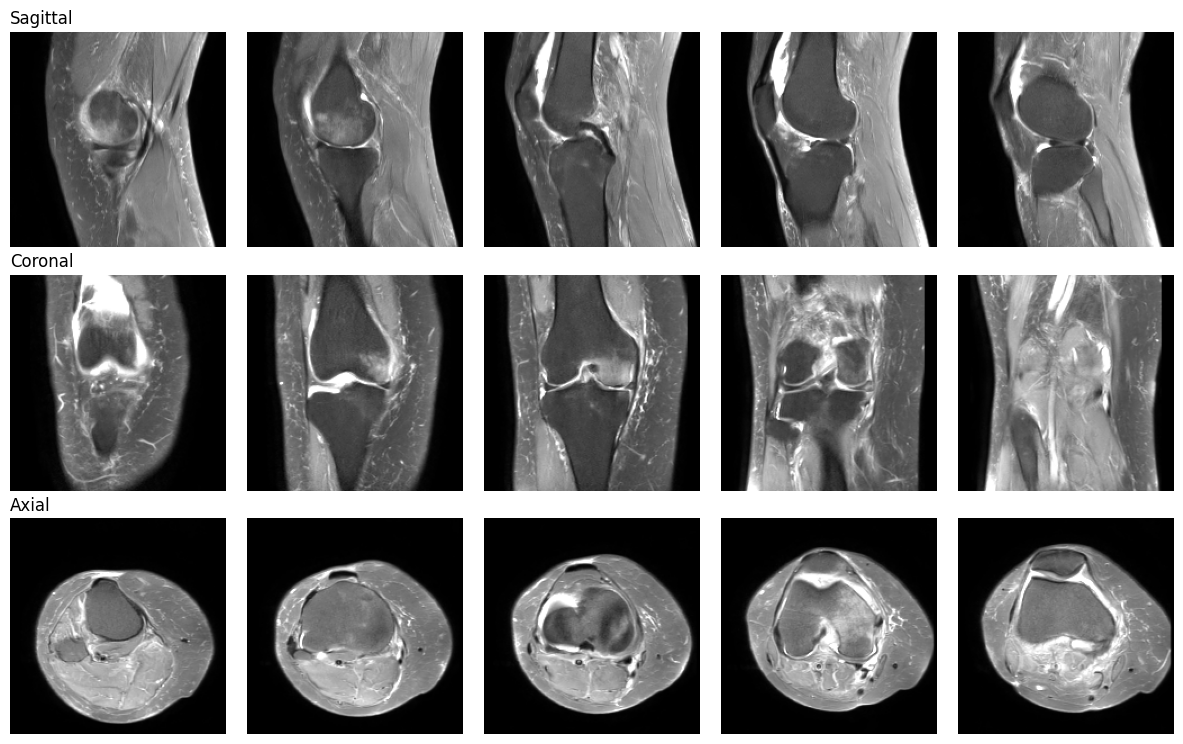

In [5]:
ts = pd.read_csv(f"{ROOT}/{SPLIT}_series.csv")
order = {s: i for i, s in enumerate(pd.read_csv(f"{ROOT}/train.csv", usecols=["StudyInstanceUID"]).StudyInstanceUID)}
jobs = [(sid, pick_series(g)) for sid, g in ts.groupby("StudyInstanceUID")]
jobs.sort(key=lambda j: order[j[0]])
print(len(jobs), "studies | with a missing plane:", sum(any(s is None for s in j[1]) for j in jobs))
t0 = time.time(); test = [process_study(j) for j in jobs[:6]]
per = (time.time() - t0) / 6
print(f"{per:.2f} s/study single process -> full run with 4 workers is about {per * len(jobs) / 4 / 60:.0f} min")
arr, info = test[0]; print(info)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(3, 5, figsize=(12, 7.5))
for p in range(3):
    for c, k in enumerate([0, 4, 8, 12, 15]):
        ax[p, c].imshow(arr[p, k], cmap="gray"); ax[p, c].axis("off")
    ax[p, 0].set_title(PLANES[p], loc="left")
plt.tight_layout(); plt.show()

# **4: Full run (resumable)**

process all 4,407 studies in shards of 500 using 4 CPU cores. If the session stops, rerun this cell and it skips finished shards.

In [8]:
from concurrent.futures import ProcessPoolExecutor
CACHE = "/kaggle/working/cache"; os.makedirs(CACHE, exist_ok=True); SH = 500
t0 = time.time()
with ProcessPoolExecutor(max_workers=4) as ex:
    for s in range(0, len(jobs), SH):
        tag = f"{s // SH:03d}"; fa, fi = f"{CACHE}/shard_{tag}.npy", f"{CACHE}/info_{tag}.csv"
        if os.path.exists(fa) and os.path.exists(fi):
            continue
        res = list(ex.map(process_study, jobs[s:s + SH], chunksize=8))
        np.save(fa, np.stack([r[0] for r in res]))
        pd.DataFrame([r[1] for r in res]).to_csv(fi, index=False)
        print(f"shard {tag} done | {len(res)} studies | {(time.time() - t0) / 60:.1f} min elapsed", flush=True)

shard 000 done | 500 studies | 3.4 min elapsed
shard 001 done | 500 studies | 6.3 min elapsed
shard 002 done | 500 studies | 9.0 min elapsed
shard 003 done | 500 studies | 11.9 min elapsed
shard 004 done | 500 studies | 14.9 min elapsed
shard 005 done | 500 studies | 17.7 min elapsed
shard 006 done | 500 studies | 20.6 min elapsed
shard 007 done | 500 studies | 23.6 min elapsed
shard 008 done | 407 studies | 26.1 min elapsed


# **5: Verify and index**

confirm that nothing failed silently, and save an index that maps each study to its shard and row.

In [9]:
CACHE = "/kaggle/working/cache"; SH = 500
print("files in cache:", len(os.listdir(CACHE)))      # should print 18

info = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(f"{CACHE}/info_*.csv"))], ignore_index=True)
print("studies cached:", len(info))
for p in PLANES:
    print(p, "ok:", int(info[f"ok_{p}"].sum()), "| failed or missing:", int((info[f"ok_{p}"] == 0).sum()))
for c in [c for c in info.columns if c.startswith("err_")]:
    print(c, info[c].dropna().value_counts().head(3).to_dict())
info["shard"] = np.arange(len(info)) // SH; info["row"] = np.arange(len(info)) % SH
info.to_csv(f"{CACHE}/cache_index.csv", index=False)
a = np.load(f"{CACHE}/shard_000.npy", mmap_mode="r")
print("shard shape:", a.shape, "| mean intensity:", round(float(a[:50].mean()), 1))
print("cache size GB:", round(sum(os.path.getsize(f) for f in glob.glob(f"{CACHE}/*.npy")) / 1e9, 2))

files in cache: 18
studies cached: 4407
Sagittal ok: 4407 | failed or missing: 0
Coronal ok: 4407 | failed or missing: 0
Axial ok: 4407 | failed or missing: 0
shard shape: (500, 3, 16, 192, 192) | mean intensity: 64.0
cache size GB: 7.8
